In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv")

print(df.shape)
df.head()

(8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [3]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [4]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Not Available")
df["country"] = df["country"].fillna("Unknown")
df["date_added"] = df["date_added"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Not Rated")

In [5]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64

In [6]:
print("Before:", df.shape)

df.drop_duplicates(inplace=True)

print("After:", df.shape)

Before: (8807, 12)
After: (8807, 12)


In [7]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [8]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

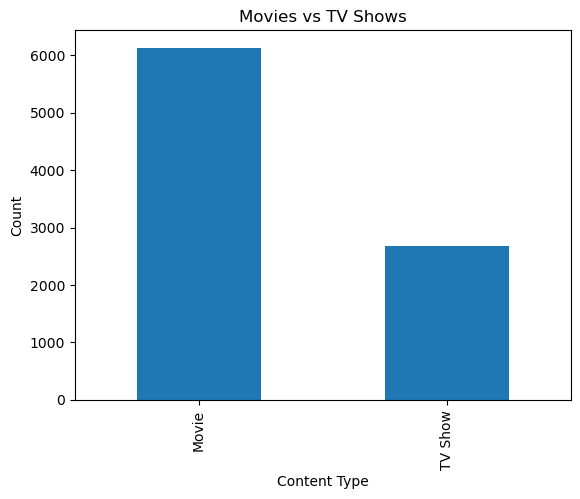

In [9]:
df["type"].value_counts().plot(kind="bar")
plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

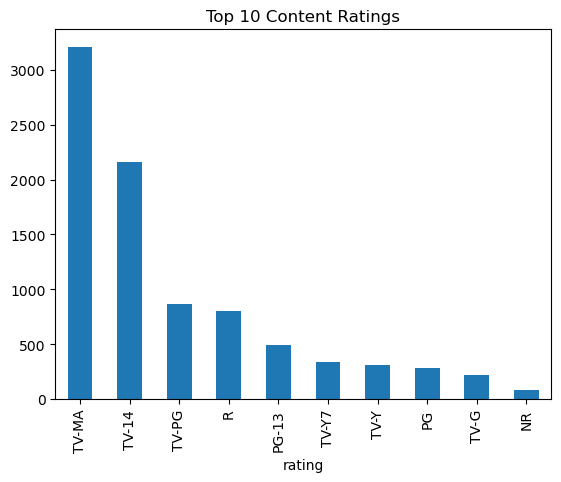

In [10]:
df["rating"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Content Ratings")
plt.show()

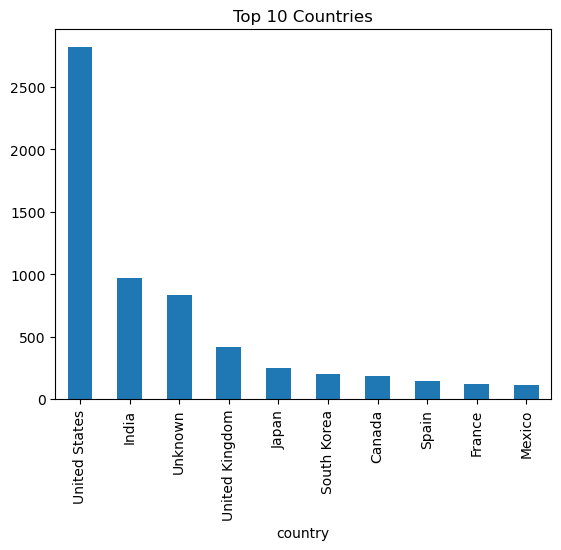

In [11]:
df["country"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Countries")
plt.show()

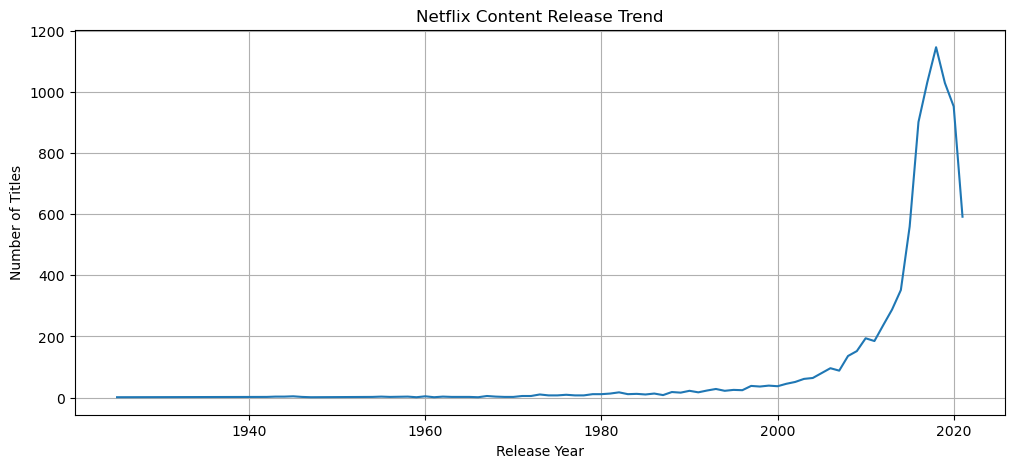

In [12]:
year_counts = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(12,5))
year_counts.plot(kind="line")
plt.title("Netflix Content Release Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()

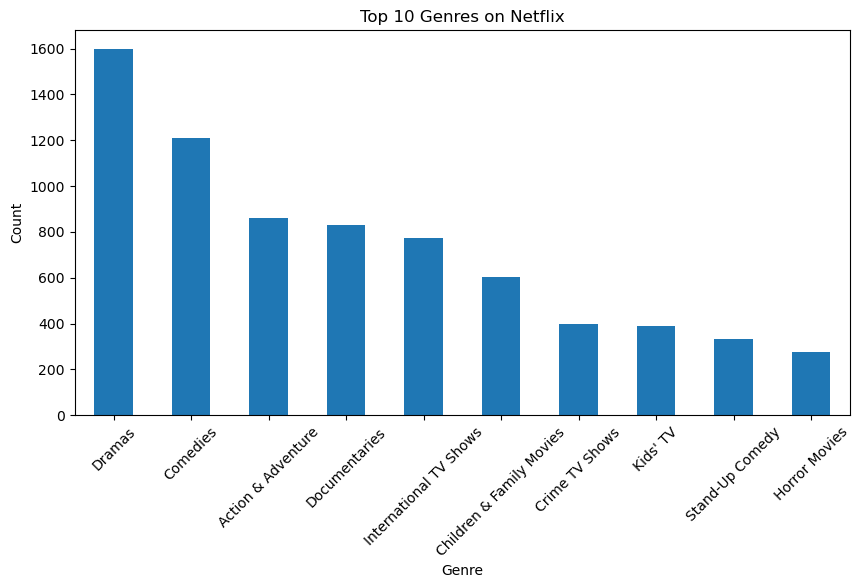

In [13]:
df["main_genre"] = df["listed_in"].str.split(",").str[0]

top_genres = df["main_genre"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_genres.plot(kind="bar")
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

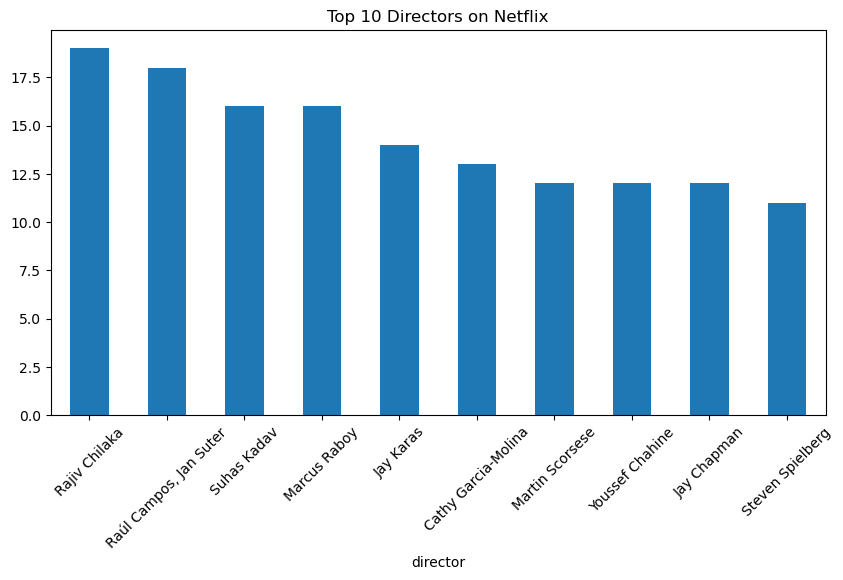

In [14]:
top_directors = df[df["director"]!="Unknown"]["director"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_directors.plot(kind="bar")
plt.title("Top 10 Directors on Netflix")
plt.xticks(rotation=45)
plt.show()

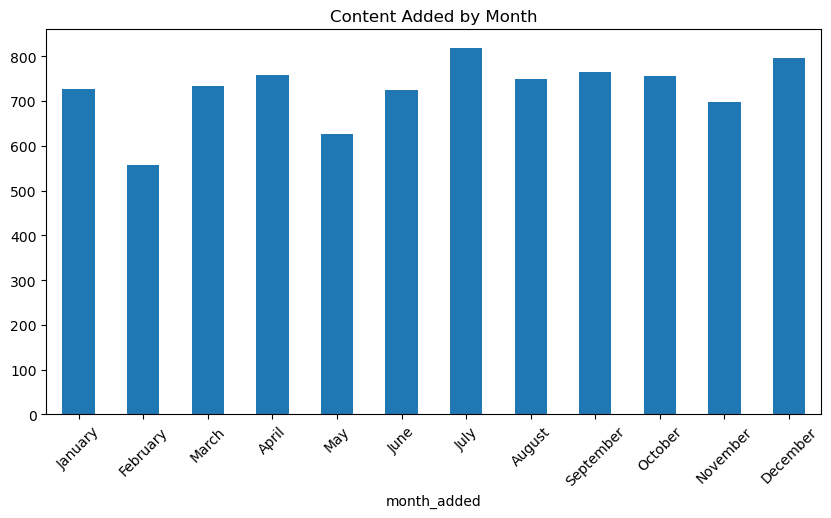

In [15]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

df["month_added"] = df["date_added"].dt.month_name()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly = df["month_added"].value_counts().reindex(month_order)

plt.figure(figsize=(10,5))
monthly.plot(kind="bar")
plt.title("Content Added by Month")
plt.xticks(rotation=45)
plt.show()

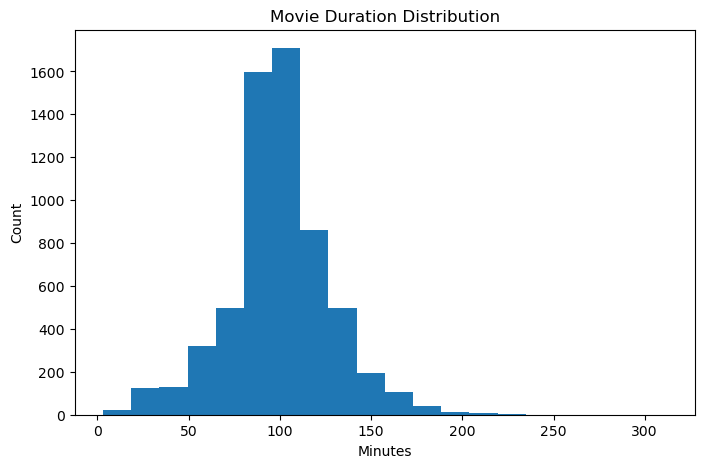

In [16]:
movies = df[df["type"]=="Movie"].copy()

movies["duration"] = movies["duration"].str.replace(" min","", regex=False)
movies["duration"] = pd.to_numeric(movies["duration"], errors="coerce")

plt.figure(figsize=(8,5))
plt.hist(movies["duration"].dropna(), bins=20)
plt.title("Movie Duration Distribution")
plt.xlabel("Minutes")
plt.ylabel("Count")
plt.show()

In [17]:
df.to_csv("netflix_cleaned.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
